# 01 · Raw data overview

What the three provided extracts contain before any cleaning: size, coverage, time span, completeness, duplicates and the content of each file.

Source: the unchanged rows in `data/raw_tables/` (`labs_raw`, `meds_raw`, `notes`), built by `scripts/03_build_raw_tables.py`. Note text is not loaded here.

Every output in this notebook is aggregate (counts, shares, distributions). No patient identifiers, row values or note text are shown. Figures are also written to `notebooks/figures/`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz

viz.use_style()
pd.set_option("display.width", 160)

RAW = ROOT / "data" / "raw_tables"
labs = pd.read_parquet(RAW / "labs_raw.parquet")
meds = pd.read_parquet(RAW / "meds_raw.parquet")
notes = pd.read_parquet(RAW / "notes.parquet")

ADDED = ["source_file", "source_row", "lab_row_id", "med_row_id", "dup_group_size", "is_exact_duplicate", "value_num", "is_censored", "censor_direction", "unit_normalised_lower", "ref_low_parsed", "ref_high_parsed"]
NOTE_ORIGINAL = {"patient": "Profile Key", "note_type": "Type", "service": "Service", "signed_status": "Signed Status", "author_type": "Authoring Provider Type", "author_specialty": "Authoring Provider Specialty", "service_year": "Service Date", "creation_year": "Creation Date", "last_edited_year": "Last Edited Date"}

sources = {
    "labs": dict(df=labs, pid="Patient", year="Result Date", cols=[c for c in labs.columns if c not in ADDED]),
    "medications": dict(df=meds, pid="Patient", year="Start Date", cols=[c for c in meds.columns if c not in ADDED]),
    "notes": dict(df=notes, pid="patient", year="service_year", cols=list(NOTE_ORIGINAL)),
}

## 1. The three files at a glance

In [2]:
rows = []
for name, s in sources.items():
    d = s["df"]
    dup = d["is_exact_duplicate"].mean() if "is_exact_duplicate" in d else np.nan
    rows.append({
        "file": name,
        "rows": len(d),
        "columns in export": {"labs": 16, "medications": 23, "notes": 11}[name],
        "patients": d[s["pid"]].nunique(),
        "rows per patient (median)": d.groupby(s["pid"]).size().median(),
        "first year": int(d[s["year"]].min()),
        "last year": int(d[s["year"]].max()),
        "exact duplicate rows": f"{dup:.0%}" if pd.notna(dup) else "n/a",
    })
overview = pd.DataFrame(rows).set_index("file")
overview

,rows,columns in export,patients,rows per patient (median),first year,last year,exact duplicate rows
file,,,,,,,
labs,43550,16,17,1775.0,2004,2027,56%
medications,5807,23,17,222.0,2001,2027,63%
notes,215,11,117,2.0,2006,2026,n/a


## 2. Which patients each file covers

The notes cover all 117 patients. Labs and medications cover the same 17. No patient with an operative report has structured labs or medications.

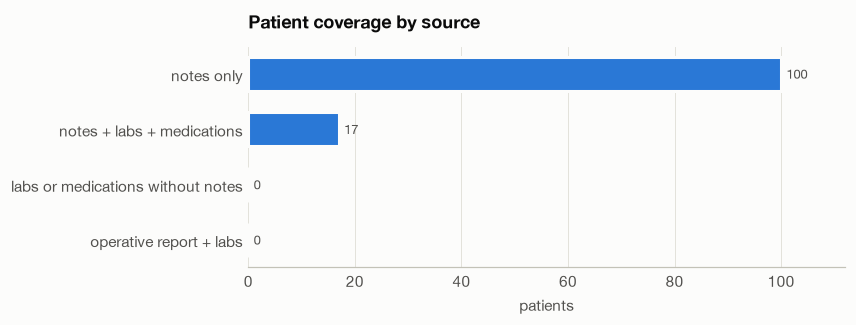

In [3]:
lab_p, med_p, note_p = set(labs.Patient), set(meds.Patient), set(notes.patient)
ops_p = set(notes.loc[notes.note_type == "Operative Report", "patient"])
groups = {
    "notes only": len(note_p - lab_p - med_p),
    "notes + labs + medications": len(note_p & lab_p & med_p),
    "labs or medications without notes": len((lab_p | med_p) - note_p),
    "operative report + labs": len(ops_p & lab_p),
}
fig, ax = plt.subplots(figsize=(7, 2.6))
viz.hbar(ax, list(groups), list(groups.values()), xlabel="patients")
ax.set_title("Patient coverage by source")
viz.save(fig, "01_patient_coverage")
plt.show()

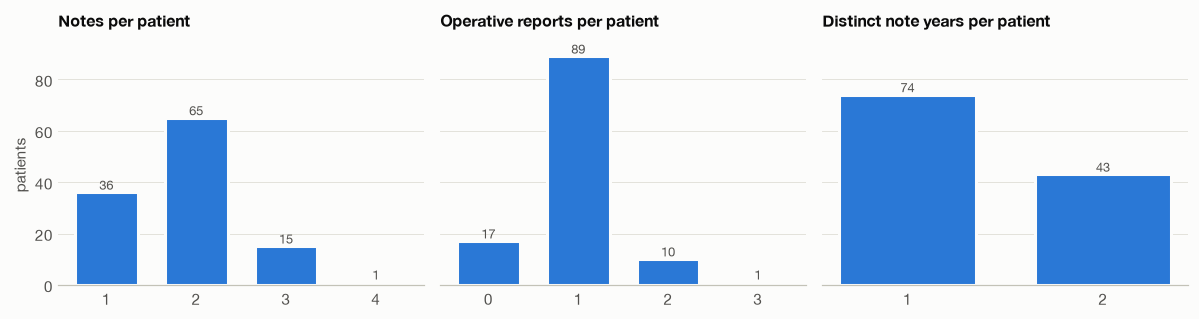

In [4]:
per_patient = notes.groupby("patient").agg(
    notes=("note_id", "size"),
    operative_reports=("note_type", lambda s: (s == "Operative Report").sum()),
    years=("service_year", "nunique"),
)
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, col, title in zip(axes, per_patient.columns, ["Notes per patient", "Operative reports per patient", "Distinct note years per patient"]):
    counts = per_patient[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, width=0.7, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=2)
    ax.set_title(title, fontsize=10.5)
    ax.set_xticks(counts.index)
    ax.grid(axis="x", visible=False)
    for x, v in counts.items():
        ax.text(x, v, f"{v}", ha="center", va="bottom", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].set_ylabel("patients")
fig.tight_layout()
viz.save(fig, "01_notes_per_patient")
plt.show()

## 3. Records over time

Dates are shifted and reduced to the year. The three files are on very different scales, so each gets its own panel on a shared year axis.

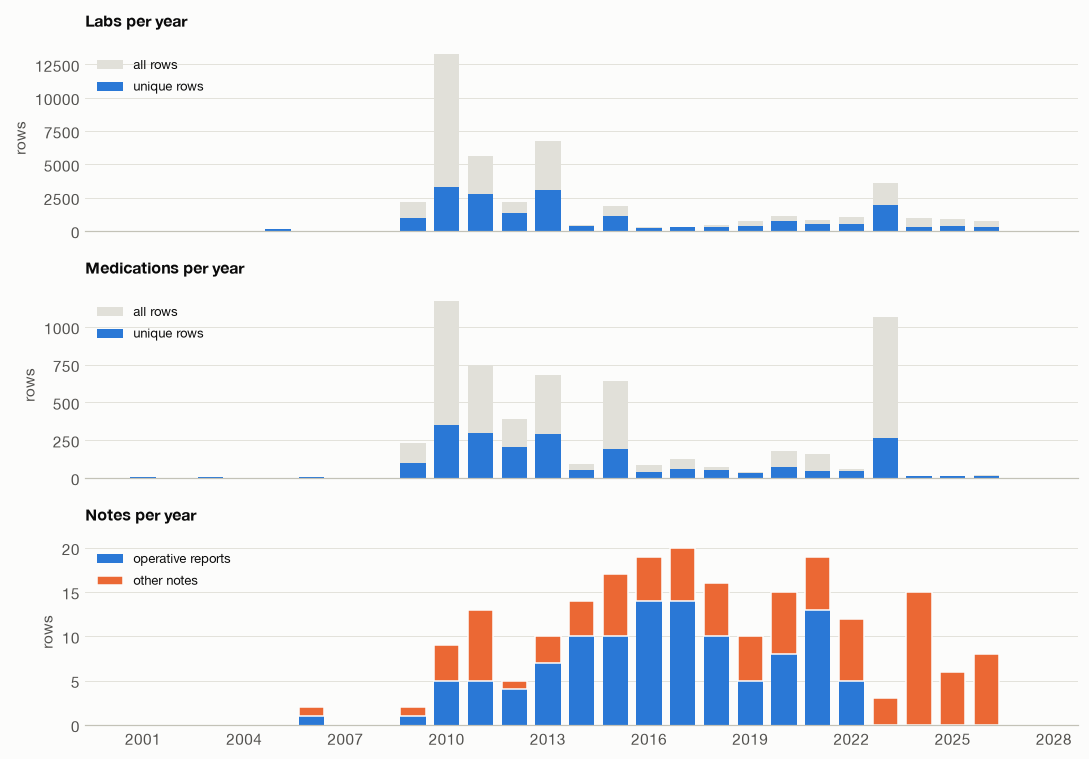

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (name, s) in zip(axes, sources.items()):
    d = s["df"]
    if "is_exact_duplicate" in d:
        all_rows = d.groupby(s["year"]).size()
        unique_rows = d[~d.is_exact_duplicate].groupby(s["year"]).size()
        ax.bar(all_rows.index, all_rows.values, width=0.75, color=viz.GRID, label="all rows")
        ax.bar(unique_rows.index, unique_rows.values, width=0.75, color=viz.SERIES[0], label="unique rows")
        ax.legend(loc="upper left", fontsize=8.5)
    else:
        by = d.groupby([s["year"], d.note_type == "Operative Report"]).size().unstack(fill_value=0)
        ax.bar(by.index, by.get(True, 0), width=0.75, color=viz.SERIES[0], label="operative reports")
        ax.bar(by.index, by.get(False, 0), bottom=by.get(True, 0), width=0.75, color=viz.SERIES[1], label="other notes", edgecolor=viz.SURFACE, linewidth=1)
        ax.legend(loc="upper left", fontsize=8.5)
    ax.set_title(f"{name.capitalize()} per year", fontsize=10.5)
    ax.set_ylabel("rows")
    viz.year_axis(ax)
fig.tight_layout()
viz.save(fig, "01_records_per_year")
plt.show()

## 4. Exact duplicate rows

A row is an exact duplicate when every original column matches an earlier row. Labs and medications are more than half duplicates.

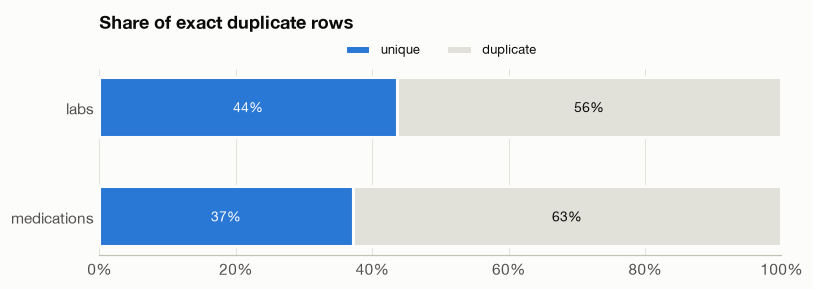

,unique,duplicate,largest repeat group
labs,19002,24548,826
medications,2157,3650,61


In [6]:
dup = pd.DataFrame({
    name: {
        "unique": (~s["df"].is_exact_duplicate).sum(),
        "duplicate": s["df"].is_exact_duplicate.sum(),
        "largest repeat group": s["df"].dup_group_size.max(),
    }
    for name, s in sources.items() if "is_exact_duplicate" in s["df"]
}).T
fig, ax = plt.subplots(figsize=(8, 2.2))
share = dup[["unique", "duplicate"]].div(dup[["unique", "duplicate"]].sum(axis=1), axis=0)
left = np.zeros(len(share))
for col, color in zip(share.columns, [viz.SERIES[0], viz.GRID]):
    ax.barh(share.index, share[col], left=left, height=0.55, color=color, edgecolor=viz.SURFACE, linewidth=2, label=col)
    for i, (v, l) in enumerate(zip(share[col], left)):
        ax.text(l + v / 2, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color=viz.SURFACE if col == "unique" else viz.INK)
    left += share[col].values
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=8.5)
ax.set_title("Share of exact duplicate rows", pad=26)
viz.save(fig, "01_duplicates")
plt.show()
dup

## 5. Column completeness

Share of rows with a value in each original column. Several columns in the exports are almost empty.

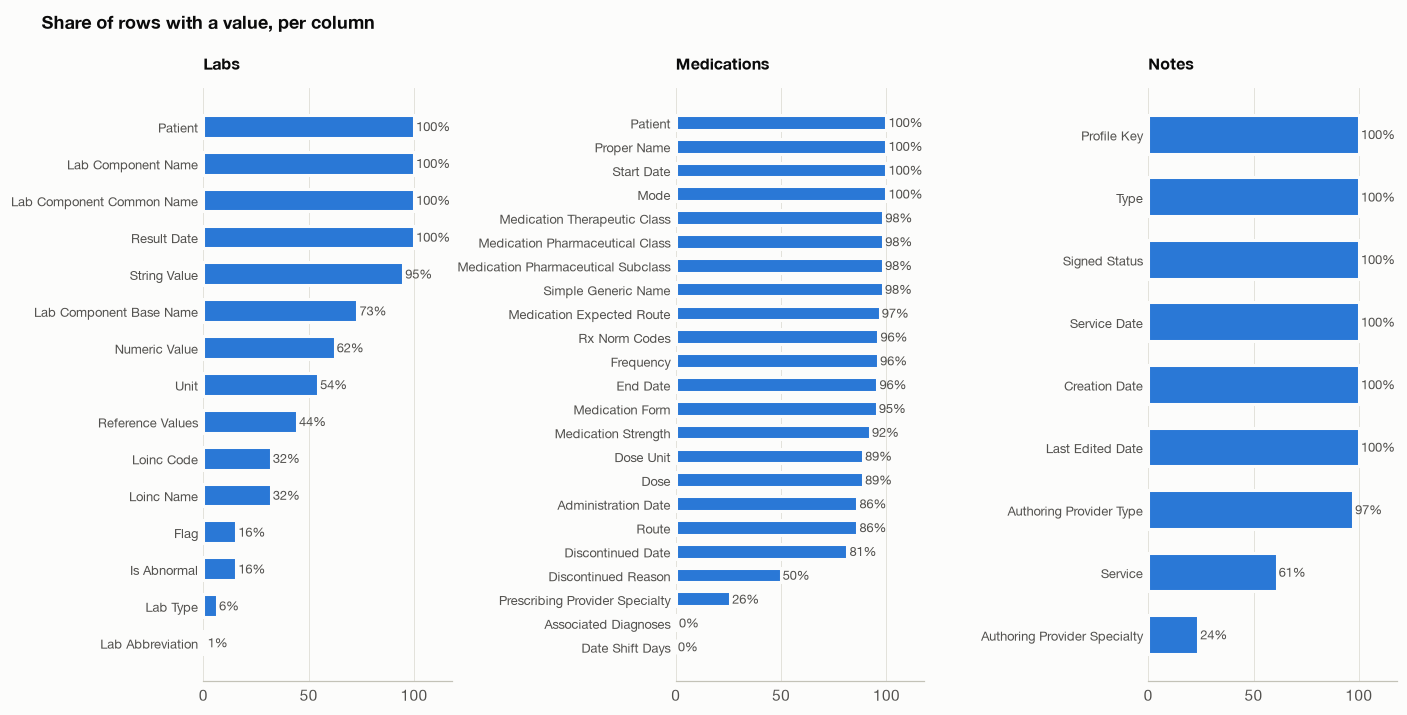

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 7), gridspec_kw=dict(wspace=0.9))
for ax, (name, s) in zip(axes, sources.items()):
    d = s["df"][s["cols"]]
    filled = d.notna().mean().sort_values(ascending=False)
    if name == "notes":
        filled.index = [NOTE_ORIGINAL.get(c, c) for c in filled.index]
    viz.hbar(ax, list(filled.index), list(filled.values * 100), value_fmt="{:.0f}%")
    ax.set_xlim(0, 118)
    ax.set_xticks([0, 50, 100])
    ax.set_title(name.capitalize(), fontsize=10.5)
    ax.tick_params(axis="y", labelsize=8.5)
fig.suptitle("Share of rows with a value, per column", x=0.02, ha="left", fontweight="bold")
viz.save(fig, "01_column_completeness")
plt.show()

## 6. Depth of follow-up per patient

How many distinct years of data each patient has, and the span from first to last year. This is what limits time-to-event modelling.

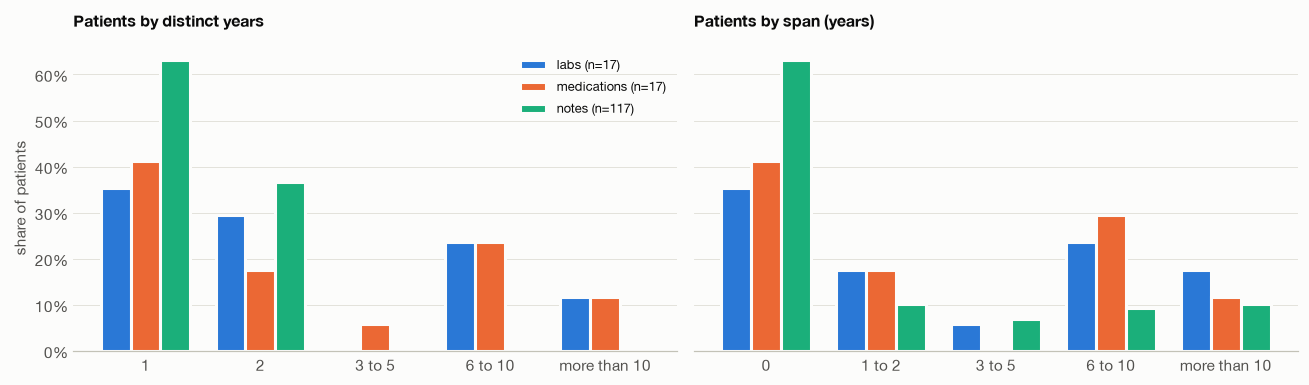

source                labs  medications  notes
distinct years count  17.0         17.0  117.0
               mean    4.9          4.7    1.4
               std     6.0          5.2    0.5
               min     1.0          1.0    1.0
               25%     1.0          1.0    1.0
               50%     2.0          2.0    1.0
               75%     8.0          8.0    2.0
               max    23.0         19.0    2.0
span (years)   count  17.0         17.0  117.0
               mean    5.2          5.1    2.4
               std     6.6          7.4    4.2
               min     0.0          0.0    0.0
               25%     0.0          0.0    0.0
               50%     1.0          1.0    0.0
               75%     9.0          8.0    3.0
               max    22.0         23.0   15.0

In [8]:
depth = []
for name, s in sources.items():
    g = s["df"].groupby(s["pid"])[s["year"]]
    depth.append(pd.DataFrame({"source": name, "distinct years": g.nunique(), "span (years)": g.max() - g.min()}))
depth = pd.concat(depth)
bins = {"distinct years": ([0, 1, 2, 5, 10, 100], ["1", "2", "3 to 5", "6 to 10", "more than 10"]),
        "span (years)": ([-1, 0, 2, 5, 10, 100], ["0", "1 to 2", "3 to 5", "6 to 10", "more than 10"])}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
names = list(sources)
width = 0.26
for ax, col in zip(axes, bins):
    edges, labels = bins[col]
    for i, name in enumerate(names):
        g = depth[depth.source == name]
        share = pd.cut(g[col], edges, labels=labels).value_counts(normalize=True).reindex(labels)
        x = np.arange(len(labels)) + (i - 1) * width
        ax.bar(x, share.values, width=width, color=viz.SERIES[i], edgecolor=viz.SURFACE, linewidth=2, label=f"{name} (n={len(g)})")
    ax.set_xticks(np.arange(len(labels)), labels)
    ax.set_title(f"Patients by {col}", fontsize=10.5)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("share of patients")
axes[0].legend(fontsize=8.5)
fig.tight_layout()
viz.save(fig, "01_followup_depth")
plt.show()
depth.groupby("source", sort=False).describe().T.round(1)

## 7. Labs file content

The labs file mixes laboratory results with other record types. `Lab Type` is empty on most rows, the same analyte appears under several component names, and unit spelling varies.

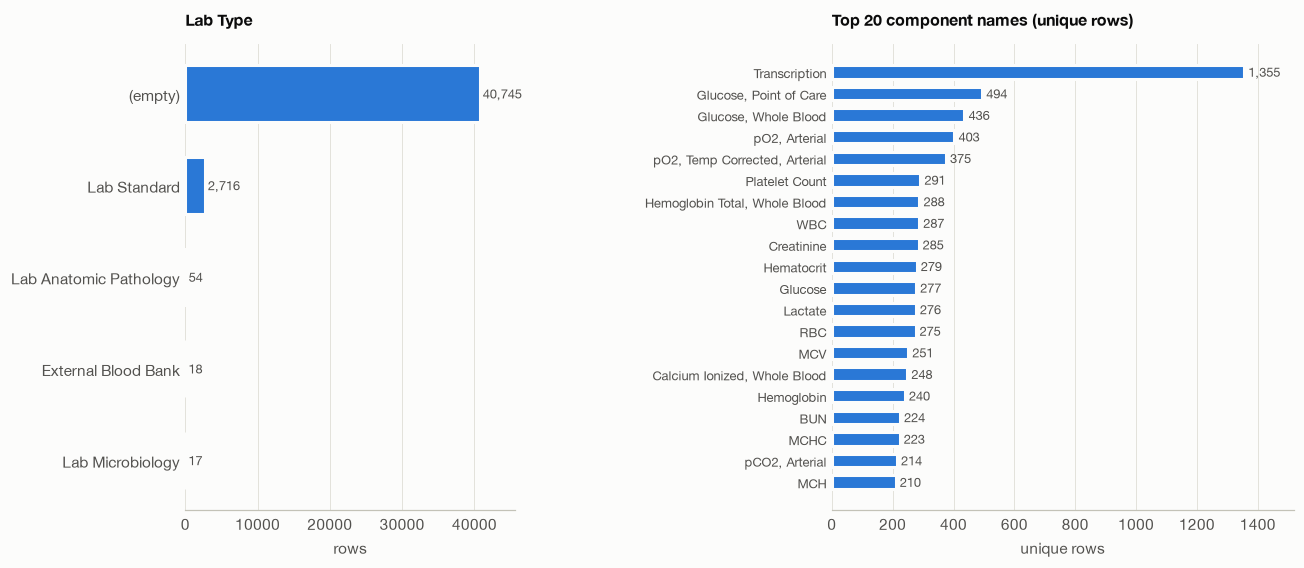

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw=dict(wspace=0.8, width_ratios=[1, 1.4]))
lab_type = labs["Lab Type"].fillna("(empty)").value_counts()
viz.hbar(axes[0], list(lab_type.index), list(lab_type.values), xlabel="rows")
axes[0].set_title("Lab Type", fontsize=10.5)
top = labs.loc[~labs.is_exact_duplicate, "Lab Component Name"].value_counts().head(20)
viz.hbar(axes[1], list(top.index), list(top.values), xlabel="unique rows")
axes[1].set_title("Top 20 component names (unique rows)", fontsize=10.5)
axes[1].tick_params(axis="y", labelsize=8.5)
viz.save(fig, "01_labs_content")
plt.show()

In [10]:
families = {
    "creatinine": r"creat(?!.*(?:clear|kinase|urine))",
    "eGFR": r"egfr|glomerular",
    "haemoglobin": r"^ha?emoglobin(?!.*(?:a1c|glyc))|^hgb",
    "calcium": r"^calcium",
    "phosphorus": r"phos",
    "LV ejection fraction": r"ejection",
}
name = labs["Lab Component Name"].fillna("").str.lower()
fam = pd.DataFrame({
    f: {
        "component names": labs.loc[name.str.contains(p, regex=True), "Lab Component Name"].nunique(),
        "LOINC codes": labs.loc[name.str.contains(p, regex=True), "Loinc Code"].nunique(),
        "unit spellings": labs.loc[name.str.contains(p, regex=True), "Unit"].nunique(),
        "patients": labs.loc[name.str.contains(p, regex=True), "Patient"].nunique(),
        "unique rows": (name.str.contains(p, regex=True) & ~labs.is_exact_duplicate).sum(),
    }
    for f, p in families.items()
}).T
coverage = pd.Series({
    "distinct component names": labs["Lab Component Name"].nunique(),
    "distinct unit strings": labs["Unit"].nunique(),
    "rows with LOINC code": f'{labs["Loinc Code"].notna().mean():.0%}',
    "rows with a numeric value": f'{labs["Numeric Value"].notna().mean():.0%}',
    "rows with an abnormal flag": f'{labs["Flag"].notna().mean():.0%}',
    "censored values (< or >)": int(labs.is_censored.sum()),
})
display(coverage.to_frame("labs"))
fam

,labs
distinct component names,703
distinct unit strings,76
rows with LOINC code,32%
rows with a numeric value,62%
rows with an abnormal flag,16%
censored values (< or >),273


,component names,LOINC codes,unit spellings,patients,unique rows
creatinine,6,3,3,17,310
eGFR,5,2,4,17,192
haemoglobin,5,3,2,17,582
calcium,4,3,2,17,476
phosphorus,2,3,2,17,213
LV ejection fraction,1,0,1,17,77


## 8. Medications file content

Mostly inpatient administration records from the index admission, with a thinner outpatient history.

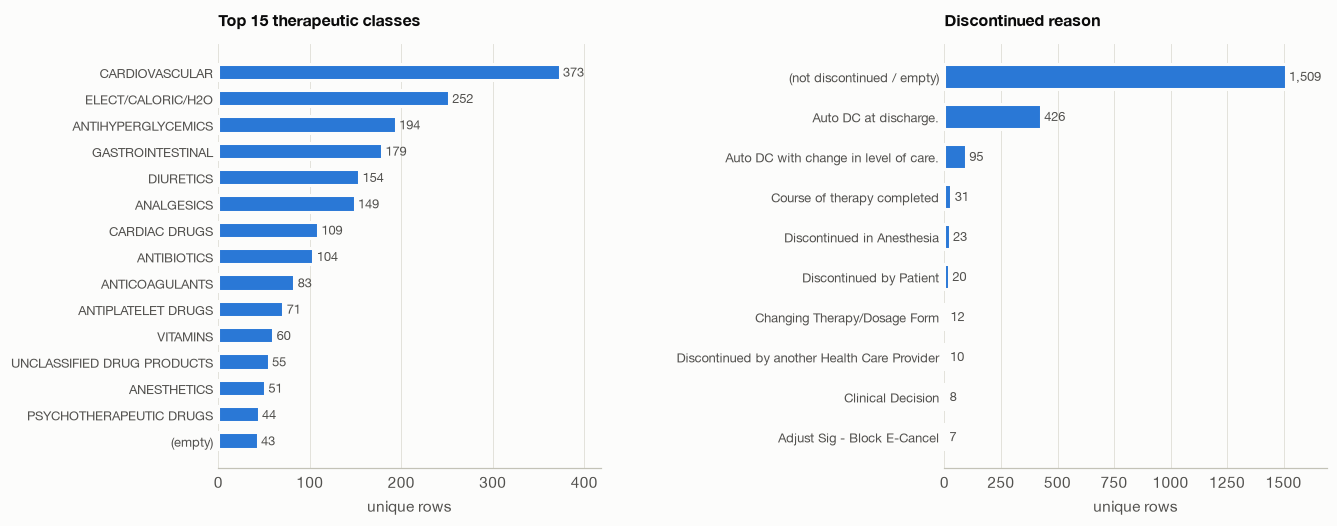

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw=dict(wspace=0.9))
u = meds[~meds.is_exact_duplicate]
cls = u["Medication Therapeutic Class"].fillna("(empty)").value_counts().head(15)
viz.hbar(axes[0], list(cls.index), list(cls.values), xlabel="unique rows")
axes[0].set_title("Top 15 therapeutic classes", fontsize=10.5)
axes[0].tick_params(axis="y", labelsize=8.5)
reason = u["Discontinued Reason"].fillna("(not discontinued / empty)").value_counts().head(10)
viz.hbar(axes[1], list(reason.index), list(reason.values), xlabel="unique rows")
axes[1].set_title("Discontinued reason", fontsize=10.5)
axes[1].tick_params(axis="y", labelsize=8.5)
viz.save(fig, "01_meds_content")
plt.show()

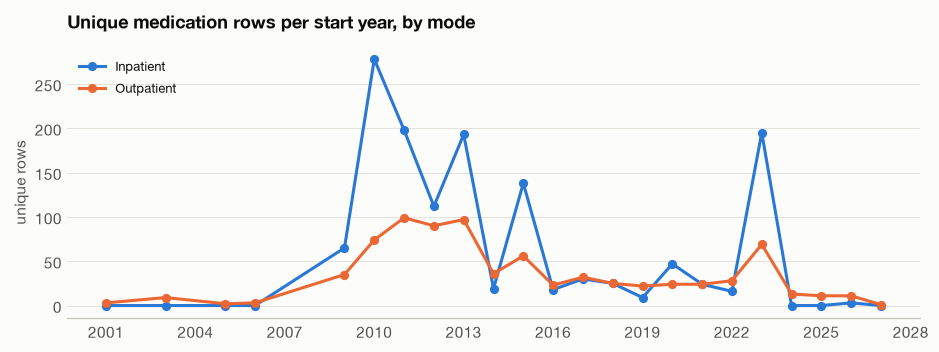

,medications
unique rows,2157
inpatient share,64%
distinct generic names,313
rows with associated diagnoses,24
Date Shift Days filled,0


In [12]:
by_mode = u.groupby(["Start Date", "Mode"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
for i, mode in enumerate(by_mode.columns):
    ax.plot(by_mode.index, by_mode[mode], color=viz.SERIES[i], marker="o", markersize=5, label=mode)
ax.set_title("Unique medication rows per start year, by mode")
ax.set_ylabel("unique rows")
ax.legend(loc="upper left", fontsize=8.5)
viz.year_axis(ax)
viz.save(fig, "01_meds_by_mode")
plt.show()
pd.Series({
    "unique rows": len(u),
    "inpatient share": f'{(u.Mode == "Inpatient").mean():.0%}',
    "distinct generic names": u["Simple Generic Name"].nunique(),
    "rows with associated diagnoses": int(u["Associated Diagnoses"].notna().sum()),
    "Date Shift Days filled": int(meds["Date Shift Days"].notna().sum()),
}).to_frame("medications")

## 9. Notes file content

Note types, signature status, length and how much was redacted. The text itself is not loaded.

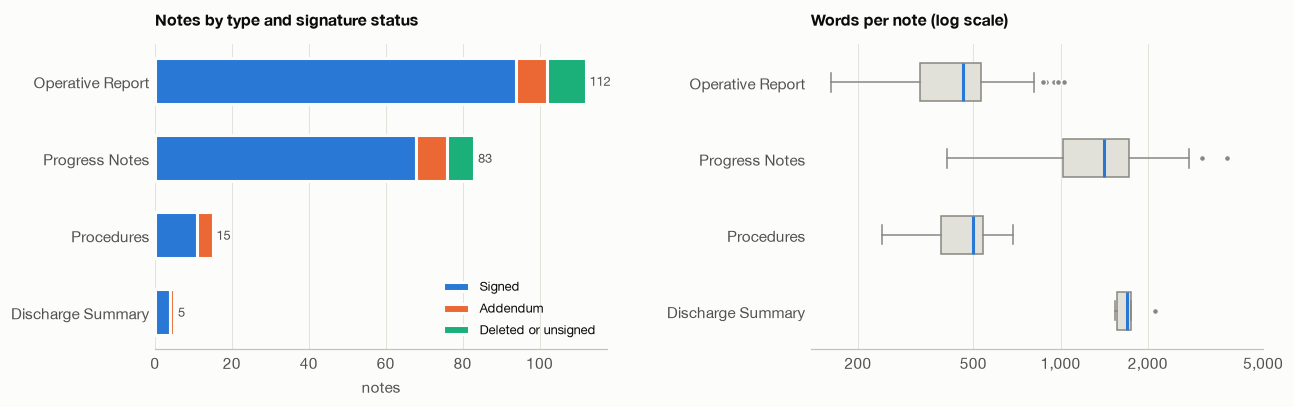

In [13]:
status = notes.assign(status=notes.signed_status.replace({"Unsigned": "Deleted or unsigned", "Deleted": "Deleted or unsigned"}))
tab = status.groupby(["note_type", "status"]).size().unstack(fill_value=0)[["Signed", "Addendum", "Deleted or unsigned"]]
tab = tab.loc[tab.sum(axis=1).sort_values(ascending=False).index]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(wspace=0.45))
left = np.zeros(len(tab))
for i, col in enumerate(tab.columns):
    axes[0].barh(tab.index, tab[col], left=left, height=0.6, color=viz.SERIES[i], edgecolor=viz.SURFACE, linewidth=2, label=col)
    left += tab[col].values
for i, v in enumerate(left):
    axes[0].text(v + 1, i, f"{int(v)}", va="center", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].invert_yaxis()
axes[0].grid(axis="y", visible=False)
axes[0].legend(fontsize=8.5, loc="lower right")
axes[0].set_title("Notes by type and signature status", fontsize=10.5)
axes[0].set_xlabel("notes")
order = list(tab.index)
axes[1].boxplot([notes.loc[notes.note_type == t, "n_words"] for t in order], orientation="horizontal", tick_labels=order, widths=0.5,
                patch_artist=True, boxprops=dict(facecolor=viz.GRID, color=viz.MUTED), medianprops=dict(color=viz.SERIES[0], linewidth=2),
                whiskerprops=dict(color=viz.MUTED), capprops=dict(color=viz.MUTED), flierprops=dict(marker="o", markersize=4, markerfacecolor=viz.MUTED, markeredgecolor=viz.SURFACE))
axes[1].invert_yaxis()
axes[1].set_xscale("log")
axes[1].set_xticks([200, 500, 1000, 2000, 5000], ["200", "500", "1,000", "2,000", "5,000"])
axes[1].minorticks_off()
axes[1].grid(axis="y", visible=False)
axes[1].set_title("Words per note (log scale)", fontsize=10.5)
viz.save(fig, "01_notes_content")
plt.show()

In [14]:
redaction = notes.groupby("note_type")[["n_date_tokens", "n_name_tokens", "n_age_tokens"]].agg(["sum", lambda s: (s > 0).mean()])
redaction.columns = [f"{a.replace('n_', '').replace('_tokens', '')} {'tokens' if b == 'sum' else 'share of notes'}" for a, b in redaction.columns]
for c in redaction.columns:
    if "share" in c:
        redaction[c] = redaction[c].map("{:.0%}".format)
display(redaction)
pd.Series({
    "notes": len(notes),
    "Service empty": f'{notes.service.isna().mean():.0%}',
    "author specialty empty": f'{notes.author_specialty.isna().mean():.0%}',
    "creation year differs from service year": int((notes.creation_year != notes.service_year).sum()),
    "median words": int(notes.n_words.median()),
}).to_frame("notes")

,date tokens,date share of notes,name tokens,name share of notes,age tokens,age share of notes
note_type,,,,,,
Discharge Summary,110,100%,133,100%,13,100%
Operative Report,383,100%,992,100%,148,90%
Procedures,32,100%,132,100%,11,73%
Progress Notes,1853,100%,1036,100%,210,93%


,notes
notes,215
Service empty,39%
author specialty empty,76%
creation year differs from service year,3
median words,577


## 10. What this means for the study

- **Two disjoint cohorts.** 100 surgical patients have operative reports and nothing structured; 17 patients have labs and medications and a single note each. A model cannot join implant details to lab trajectories for any patient in this extract.
- **Echo data lives in text only.** Every durability endpoint (mean gradient, EOA, DVI, regurgitation) has to come from note extraction, which is why notebooks 01 to 03 exist.
- **Follow-up is thin.** Most surgical patients have notes from a single year, so few have the repeated post-implant echoes that change-from-reference definitions need.
- **Structured files need cleaning before use.** More than half the lab and medication rows are exact duplicates, one analyte appears under several names and unit spellings, and most medication rows are inpatient orders from the index admission.
- **Time resolution is one year.** Dates are shifted and truncated, so event times are interval-censored at year level at best.

These findings shape the data request in `data/data_plan.md` and the preprocessing steps in `02_preprocessing.ipynb`.